In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib import colors
from matplotlib import rc
import matplotlib.patches as mpatches
from Tools.Utils import calculate_mouse_centers, calculate_mouse_distance


In [3]:
def load_task1_data(data_path):
  """
  Load data for task 1:
      The vocaubulary tells you how to map behavior names to class ids;
      it is the same for all sequences in this dataset.
  """
  data_dict = np.load(data_path, allow_pickle=True).item()
  dataset = data_dict['annotator-id_0']
  # Get any sequence key.
  sequence_id = list(data_dict['annotator-id_0'].keys())[0]
  vocabulary = data_dict['annotator-id_0'][sequence_id]['metadata']['vocab']
  return dataset, vocabulary

training_data, vocab = load_task1_data('./Caltech/calms21_task1_train.npy')
test_data, _ = load_task1_data('./Caltech/calms21_task1_test.npy')

In [4]:
# Helper functions for visualization

rc('animation', html='jshtml')

# Note: Image processing may be slow if too many frames are animated.

# Plotting constants
FRAME_WIDTH_TOP = 1024
FRAME_HEIGHT_TOP = 570

RESIDENT_COLOR = 'lawngreen'
INTRUDER_COLOR = 'skyblue'

PLOT_MOUSE_START_END = [(0, 1), (0, 2), (1, 3), (2, 3), (3, 4),
                        (3, 5), (4, 6), (5, 6), (1, 2)]
class_to_color = {'other': 'white', 'attack' : 'red', 'mount' : 'green',
                  'investigation': 'orange'}
class_to_number = {s: i for i, s in enumerate(vocab)}
number_to_class = {i: s for i, s in enumerate(vocab)}


def num_to_text(anno_list):
  return np.vectorize(number_to_class.get)(anno_list)


def set_figax():
  fig = plt.figure(figsize=(6, 4))

  img = np.zeros((FRAME_HEIGHT_TOP, FRAME_WIDTH_TOP, 3))

  ax = fig.add_subplot(111)
  ax.imshow(img)

  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  return fig, ax


def plot_mouse(ax, pose, color):
  # Draw each keypoint
  for j in range(7):
    ax.plot(pose[j, 0], pose[j, 1], 'o', color=color, markersize=5)

  # Draw a line for each point pair to form the shape of the mouse

  for pair in PLOT_MOUSE_START_END:
    line_to_plot = pose[pair, :]
    ax.plot(line_to_plot[:, 0], line_to_plot[
            :, 1], color=color, linewidth=1)

  # Draw the center point averaged over all keypoints
  center = np.nanmean(pose, axis=0)
  ax.plot(center[0], center[1], marker='X', color=color,
          markeredgecolor='white', markeredgewidth=1.5,
          markersize=9, zorder=4)


def animate_pose_sequence(video_name, keypoint_sequence, start_frame = 0, stop_frame = 100,
                          annotation_sequence = None):
  # Returns the animation of the keypoint sequence between start frame
  # and stop frame. Optionally can display annotations.
  seq = keypoint_sequence.transpose((0,1,3,2))
  center_sequence = calculate_mouse_centers(keypoint_sequence)
  distance_sequence = calculate_mouse_distance(keypoint_sequence)

  image_list = []

  counter = 0
  for j in range(start_frame, stop_frame):
    if counter%20 == 0:
      print("Processing frame ", j)
    fig, ax = set_figax()
    plot_mouse(ax, seq[j, 0, :, :], color=RESIDENT_COLOR)
    plot_mouse(ax, seq[j, 1, :, :], color=INTRUDER_COLOR)

    centers = center_sequence[j]
    ax.plot(centers[:, 0], centers[:, 1], color='white', linestyle='--',
            linewidth=1.5, alpha=0.9, zorder=2)
    plt.text(50, 20, 'distance: {:.1f} px'.format(distance_sequence[j]),
             fontsize=12, color='white',
             bbox=dict(facecolor='black', edgecolor='white', alpha=0.6))

    if annotation_sequence is not None:
      annot = annotation_sequence[j]
      annot = number_to_class[annot]
      plt.text(50, -20, annot, fontsize=16,
               bbox=dict(facecolor=class_to_color[annot], alpha=0.5))

    ax.set_title(
        video_name + '\n frame {:03d}.png'.format(j))

    ax.axis('off')
    fig.tight_layout(pad=0)
    ax.margins(0)

    fig.canvas.draw()
    # image_from_plot = np.frombuffer(fig.canvas.tostring_rgb(),
    #                                 dtype=np.uint8)
    # image_from_plot = image_from_plot.reshape(
    #     fig.canvas.get_width_height()[::-1] + (3,))
    image_from_plot = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]

    image_list.append(image_from_plot)

    plt.close()
    counter = counter + 1

  # Plot animation.
  fig = plt.figure()
  plt.axis('off')
  im = plt.imshow(image_list[0])

  def animate(k):
      im.set_array(image_list[k])
      return im,
  ani = animation.FuncAnimation(fig, animate, frames=len(image_list), blit=True)
  return ani


def plot_behavior_raster(annotation_sequence, start_frame=0,
                         stop_frame=100,
                         title="Behavior Labels"):
  # Plot annotations as a behavior raster

  # Map annotations to a number.
  annotation_num = []
  for item in annotation_sequence[start_frame:stop_frame]:
    annotation_num.append(class_to_number[item])

  all_classes = list(set(annotation_sequence[start_frame:stop_frame]))

  cmap = colors.ListedColormap(['red', 'orange', 'green', 'white'])
  bounds=[-0.5, 0.5, 1.5, 2.5, 3.5]
  norm = colors.BoundaryNorm(bounds, cmap.N)

  height = 200
  arr_to_plot = np.repeat(np.array(annotation_num)[:, np.newaxis].transpose(),
                                                  height, axis = 0)

  fig, ax = plt.subplots(figsize = (16, 3))
  ax.imshow(arr_to_plot, interpolation='none',cmap=cmap, norm=norm)

  ax.set_yticks([])
  ax.set_xlabel('Frame Number')
  plt.title(title)

  legend_patches = []
  for item in all_classes:
    legend_patches.append(mpatches.Patch(color=class_to_color[item], label=item))

  plt.legend(handles=legend_patches,loc='center left', bbox_to_anchor=(1, 0.5))

  plt.tight_layout()

In [5]:
import numpy as np

# 读test文件，看数据形状
train_data = np.load("./Caltech/calms21_task1_train.npy", allow_pickle=True).item()

print(type(train_data))
# print(train_data.keys())
# print(train_data['annotator-id_0'].keys())
data_0 = train_data['annotator-id_0']['task1/train/mouse001_task1_annotator1']
data_1 = train_data['annotator-id_0']['task1/train/mouse002_task1_annotator1']
data_69 = train_data['annotator-id_0']['task1/train/mouse070_task1_annotator1']
print(data_0['annotations'].shape, data_1['annotations'].shape, data_69['annotations'].shape)
print(data_0['scores'].shape, data_1['scores'].shape, data_69['scores'].shape)
print(data_0['keypoints'].shape, data_1['keypoints'].shape, data_69['keypoints'].shape)
print(data_0['metadata']['vocab'], data_1['metadata']['vocab'], data_69['metadata']['vocab'])
print('---------------------------------')

print(data_1['annotations'][:40])


<class 'dict'>
(21364,) (19343,) (12537,)
(21364, 2, 7) (19343, 2, 7) (12537, 2, 7)
(21364, 2, 2, 7) (19343, 2, 2, 7) (12537, 2, 2, 7)
{'attack': 0, 'investigation': 1, 'mount': 2, 'other': 3} {'attack': 0, 'investigation': 1, 'mount': 2, 'other': 3} {'attack': 0, 'investigation': 1, 'mount': 2, 'other': 3}
---------------------------------
[3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3]


In [19]:
print('---------find attach---------')
has_attack = []
for key in train_data['annotator-id_0']:
    d = train_data['annotator-id_0'][key]
    if np.any(d['annotations'] == 0):
        has_attack.append(key)
print('has Attack: ', len(has_attack), has_attack)

---------find attach---------
has Attack:  18 ['task1/train/mouse002_task1_annotator1', 'task1/train/mouse005_task1_annotator1', 'task1/train/mouse006_task1_annotator1', 'task1/train/mouse007_task1_annotator1', 'task1/train/mouse008_task1_annotator1', 'task1/train/mouse018_task1_annotator1', 'task1/train/mouse019_task1_annotator1', 'task1/train/mouse027_task1_annotator1', 'task1/train/mouse028_task1_annotator1', 'task1/train/mouse030_task1_annotator1', 'task1/train/mouse034_task1_annotator1', 'task1/train/mouse036_task1_annotator1', 'task1/train/mouse042_task1_annotator1', 'task1/train/mouse045_task1_annotator1', 'task1/train/mouse048_task1_annotator1', 'task1/train/mouse050_task1_annotator1', 'task1/train/mouse064_task1_annotator1', 'task1/train/mouse070_task1_annotator1']


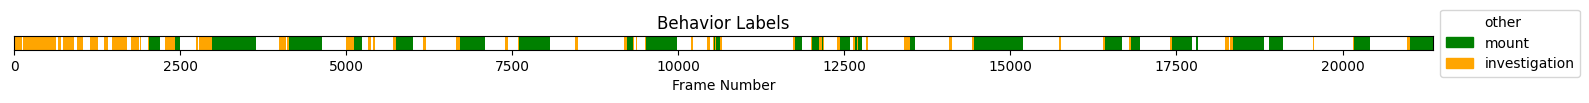

In [6]:
attack_trial = ['task1/train/mouse002_task1_annotator1', 'task1/train/mouse005_task1_annotator1', 'task1/train/mouse006_task1_annotator1', 'task1/train/mouse007_task1_annotator1', 'task1/train/mouse008_task1_annotator1', 'task1/train/mouse018_task1_annotator1', 'task1/train/mouse019_task1_annotator1', 'task1/train/mouse027_task1_annotator1', 'task1/train/mouse028_task1_annotator1', 'task1/train/mouse030_task1_annotator1', 'task1/train/mouse034_task1_annotator1', 'task1/train/mouse036_task1_annotator1', 'task1/train/mouse042_task1_annotator1', 'task1/train/mouse045_task1_annotator1', 'task1/train/mouse048_task1_annotator1', 'task1/train/mouse050_task1_annotator1', 'task1/train/mouse064_task1_annotator1', 'task1/train/mouse070_task1_annotator1']

for i in range(len(attack_trial)):
    data_attack = train_data['annotator-id_0'][attack_trial[i]]
    annotation_sequence = data_attack['annotations']
    text_sequence = num_to_text(annotation_sequence)

    plot_behavior_raster(
        text_sequence,
        start_frame=0,
        stop_frame=len(annotation_sequence),
        title=attack_trial[i]
        )